In [3]:
import pandas as pd

import sys
sys.path.append("..")

import warnings
warnings.filterwarnings('ignore')

DATA_FOLDER = "data/"
OUTPUT_FOLDER = "outputs/"

SEED = 404

### Functions

In [4]:
def apply_to_train_test(func):
    global train, test

    train, test = func(train), func(test)

In [5]:
def drop_columns(df: pd.DataFrame):
    return df.drop(columns=["Unnamed: 0", "Case_ID"])

def encode_y(df: pd.DataFrame):
    return df.replace({"GBM": 1, "LGG": 0})

train = pd.read_csv(DATA_FOLDER + "train.csv")
test = pd.read_csv(DATA_FOLDER + "test.csv")
apply_to_train_test(drop_columns)
train = encode_y(train)
train.head()

,Grade,Gender,Age_at_diagnosis,Primary_Diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,1,Male,79 years 183 days,Glioblastoma,black or african american,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
1,0,Male,53 years 197 days,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED
2,0,Female,61 years 305 days,"Astrocytoma, NOS",white,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
3,0,Female,58 years 55 days,Mixed glioma,white,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
4,0,Male,30 years 113 days,"Astrocytoma, NOS",white,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED


In [6]:
def prepare_age(df: pd.DataFrame):
    df["Age_at_diagnosis"] = df["Age_at_diagnosis"].replace({"--": None, "not reported": None})
    df["Age_at_diagnosis"] = df["Age_at_diagnosis"].apply(lambda x: int(x.split(" ")[0]) if x else x)
    median = df["Age_at_diagnosis"].median(skipna=True)
    df["Age_at_diagnosis"] = df["Age_at_diagnosis"].fillna(int(median))
    return df

apply_to_train_test(prepare_age)
train.head(2)

,Grade,Gender,Age_at_diagnosis,Primary_Diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,1,Male,79.0,Glioblastoma,black or african american,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
1,0,Male,53.0,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED


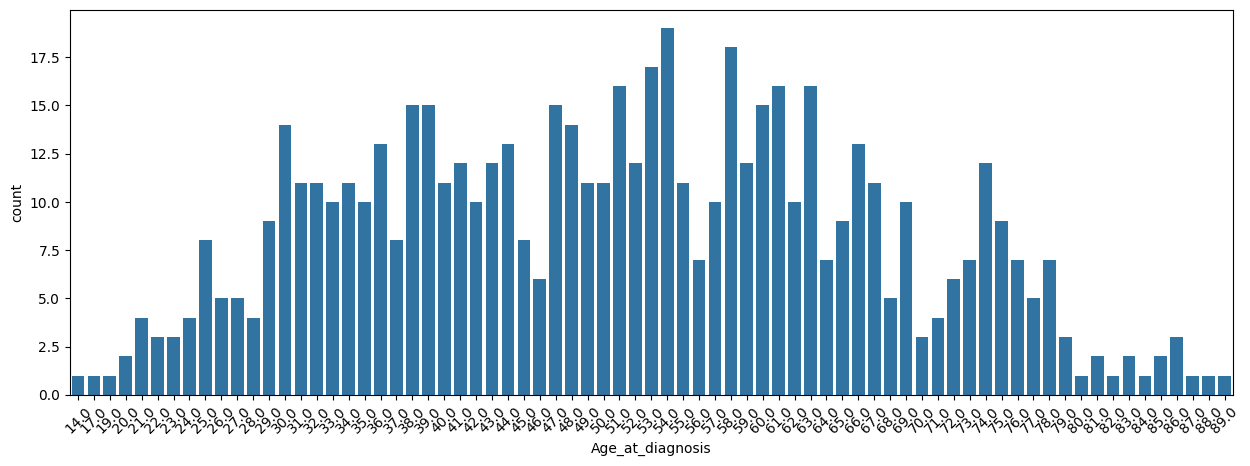

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
sns.countplot(data=train.sort_values(by="Age_at_diagnosis"), x="Age_at_diagnosis")
plt.xticks(rotation=45);

In [8]:
from sklearn.preprocessing import OneHotEncoder

def sort_df(df: pd.DataFrame):
    return df.sort_index(axis=1)

def encode_categorical_data(df: pd.DataFrame):
    categorical_columns = train.drop(columns=["Age_at_diagnosis", "Grade"]).columns
    return pd.get_dummies(df, columns=categorical_columns, dtype=int)

apply_to_train_test(sort_df)
apply_to_train_test(encode_categorical_data)

for col in train.drop(columns=["Grade"]).columns:
    if col not in test.columns:
        test[col] = 0

assert set(train.drop(columns=["Grade"]).columns) == set(test.columns)

train.head(2)

,Age_at_diagnosis,Grade,ATRX_MUTATED,ATRX_NOT_MUTATED,BCOR_MUTATED,BCOR_NOT_MUTATED,CIC_MUTATED,CIC_NOT_MUTATED,CSMD3_MUTATED,CSMD3_NOT_MUTATED,...,Race_--,Race_american indian or alaska native,Race_asian,Race_black or african american,Race_not reported,Race_white,SMARCA4_MUTATED,SMARCA4_NOT_MUTATED,TP53_MUTATED,TP53_NOT_MUTATED
0,79.0,1,0,1,0,1,0,1,0,1,...,0,0,0,1,0,0,0,1,0,1
1,53.0,0,0,1,0,1,0,1,0,1,...,0,0,0,0,0,1,0,1,1,0


In [9]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
scaler = scaler.fit(pd.DataFrame(train["Age_at_diagnosis"]))

def standardization(df):
    df["Age_at_diagnosis"] = scaler.transform(pd.DataFrame(df["Age_at_diagnosis"]))
    return df

apply_to_train_test(standardization)
train.head(2)

,Age_at_diagnosis,Grade,ATRX_MUTATED,ATRX_NOT_MUTATED,BCOR_MUTATED,BCOR_NOT_MUTATED,CIC_MUTATED,CIC_NOT_MUTATED,CSMD3_MUTATED,CSMD3_NOT_MUTATED,...,Race_--,Race_american indian or alaska native,Race_asian,Race_black or african american,Race_not reported,Race_white,SMARCA4_MUTATED,SMARCA4_NOT_MUTATED,TP53_MUTATED,TP53_NOT_MUTATED
0,1.796489,1,0,1,0,1,0,1,0,1,...,0,0,0,1,0,0,0,1,0,1
1,0.135012,0,0,1,0,1,0,1,0,1,...,0,0,0,0,0,1,0,1,1,0


### NN

In [97]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import random
from sklearn.model_selection import train_test_split

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed_all(SEED)

apply_to_train_test(sort_df)

X_train, X_valid, y_train, y_valid = \
    train_test_split(train.drop(columns="Grade"), train["Grade"], test_size=0.2, random_state=SEED)


X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_valid_tensor = torch.tensor(X_valid.values, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid.values, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

class BinaryClassifier(nn.Module):
    def __init__(self, input_dim):
        super(BinaryClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)  
        self.fc2 = nn.Linear(64, 32)
        self.dropout = nn.Dropout(0.5)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc3(x))
        return x


input_dim = X_train.shape[1]
model = BinaryClassifier(input_dim)

criterion = nn.BCELoss()
# L2 regularization (Weight Decay) adds a penalty proportional to the square of the magnitude of the weights to the loss function.
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)

num_epochs = 20
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in valid_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
        
        val_loss /= len(valid_loader)
        val_losses.append(val_loss)
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

Epoch [1/20], Train Loss: 0.6905, Val Loss: 0.6595
Epoch [2/20], Train Loss: 0.6422, Val Loss: 0.6098
Epoch [3/20], Train Loss: 0.5627, Val Loss: 0.5254
Epoch [4/20], Train Loss: 0.4647, Val Loss: 0.4166
Epoch [5/20], Train Loss: 0.3580, Val Loss: 0.3092
Epoch [6/20], Train Loss: 0.2643, Val Loss: 0.2415
Epoch [7/20], Train Loss: 0.1962, Val Loss: 0.1940
Epoch [8/20], Train Loss: 0.1513, Val Loss: 0.1521
Epoch [9/20], Train Loss: 0.1274, Val Loss: 0.1237
Epoch [10/20], Train Loss: 0.1108, Val Loss: 0.0870
Epoch [11/20], Train Loss: 0.0873, Val Loss: 0.0660
Epoch [12/20], Train Loss: 0.0691, Val Loss: 0.0459
Epoch [13/20], Train Loss: 0.0652, Val Loss: 0.0333
Epoch [14/20], Train Loss: 0.0502, Val Loss: 0.0256
Epoch [15/20], Train Loss: 0.0470, Val Loss: 0.0283
Epoch [16/20], Train Loss: 0.0368, Val Loss: 0.0189
Epoch [17/20], Train Loss: 0.0330, Val Loss: 0.0163
Epoch [18/20], Train Loss: 0.0321, Val Loss: 0.0159
Epoch [19/20], Train Loss: 0.0316, Val Loss: 0.0142
Epoch [20/20], Train 

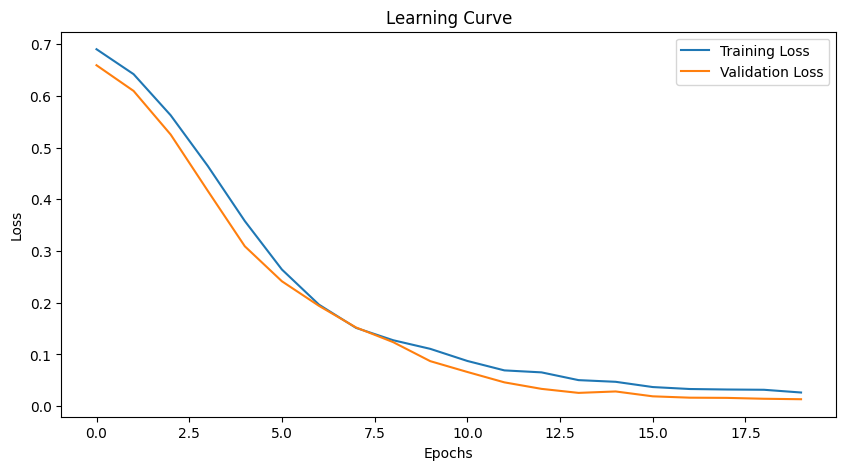

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Learning Curve')
plt.legend()
plt.show()

In [18]:
input_data = torch.tensor(test.values, dtype=torch.float32)
model.eval()
with torch.no_grad():
    predictions = model(input_data)

print(predictions)

tensor([[0.0064],
        [0.0091],
        [0.0062],
        [0.9974],
        [0.9891],
        [0.0045],
        [0.0105],
        [0.9852],
        [0.9941],
        [0.0093],
        [0.1515],
        [0.8858],
        [0.0084],
        [0.9879],
        [0.0205],
        [0.0044],
        [0.9812],
        [0.9929],
        [0.0237],
        [0.0072],
        [0.1813],
        [0.9944],
        [0.0330],
        [0.0072],
        [0.0124],
        [0.0061],
        [0.0302],
        [0.0432],
        [0.9835],
        [0.0043],
        [0.0047],
        [0.9812],
        [0.0043],
        [0.0024],
        [0.9933],
        [0.0034],
        [0.0413],
        [0.0091],
        [0.0045],
        [0.9853],
        [0.0094],
        [0.9975],
        [0.9793],
        [0.9933],
        [0.0067],
        [0.9976],
        [0.8519],
        [0.0031],
        [0.9928],
        [0.9924],
        [0.0794],
        [0.0821],
        [0.9939],
        [0.9871],
        [0.0047],
        [0

In [19]:
submission = pd.read_csv(DATA_FOLDER + "sample_submission_file.csv")
answers = pd.Series(predictions.view(-1) > 0.5).astype(int)
submission["Grade"] = answers
submission

,Id,Grade
0,0,0
1,1,0
2,2,0
3,3,1
4,4,1
...,...,...
254,254,0
255,255,0
256,256,0
257,257,1


In [109]:
from utils import save_submission
save_submission(submission, OUTPUT_FOLDER, None)

In [22]:
first = pd.read_csv(OUTPUT_FOLDER + "sub_20240915_204030.csv")
# second = pd.read_csv(OUTPUT_FOLDER + "sub_20240913_130441.csv")
second = submission

(first["Grade"] == second["Grade"]).sum()

np.int64(257)